In [2]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [29]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2,
                            n_clusters_per_class=1)
Xm, ym = make_moons(n_samples=2502, random_state=259202, noise=0.1)

In [30]:
y = np.where(y == 0, -1, 1)
ym = np.where(ym == 0, -1, 1)

In [31]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

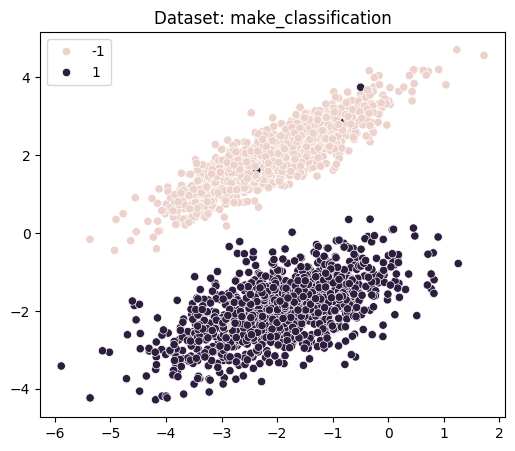

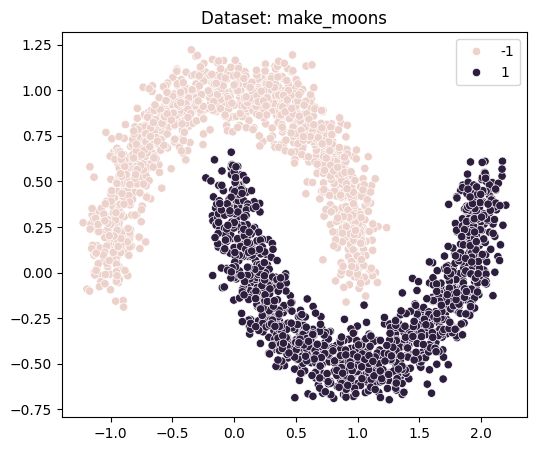

In [32]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)

In [34]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.05
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    Z = Z.reshape(xx.shape)

    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)

    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

# Neuron 

In [37]:
class Neuron:
    def __init__(self, input_dim, lr=0.1, activation='sigmoid', *, lr_min=None, lr_max=None, batch_size=None):
        self.w = np.random.randn(input_dim + 1)
        self.lr = lr
        self.activation = activation
        self.lr_min = lr if lr_min is None else lr_min
        self.lr_max = lr if lr_max is None else lr_max
        self.batch_size = batch_size
        
    def _add_bias(self, X):
        return np.c_[X, np.ones(X.shape[0])]
    
    def _activation(self, s):
        match self.activation:
            case 'sigmoid':
                return 1 / (1 + np.exp(-s))
            case 'heaviside':
                return np.heaviside(s, 1)
            case 'sin':
                return np.sin(s)
            case 'tanh':
                return np.tanh(s)
            case 'sign':
                return np.sign(s)
            case 'relu':
                return np.maximum(0, s)
            case 'leaky_relu':
                return np.where(s > 0, s, 0.01 * s)
            case _:
                raise NotImplementedError
    
    def _activation_derivative(self, s):
        match self.activation:
            case 'sigmoid':
                sig = self._activation(s)
                return sig * (1 - sig)
            case 'heaviside':
                return np.ones_like(s)
            case 'sin':
                return np.cos(s)
            case 'tanh':
                return 1 - np.tanh(s) ** 2
            case 'sign':
                return np.ones_like(s)
            case 'relu':
                return (s > 0).astype(float)
            case 'leaky_relu':
                return np.where(s > 0, 1.0, 0.01)
            case _:
                raise NotImplementedError
    
    def predict(self, X):
        X_ = self._add_bias(X)
        s = X_ @ self.w
        y = self._activation(s)
        if self.activation in ['tanh', 'sign', 'sin']:
            return np.where(y >= 0, 1, -1)
        else:
            return np.where(y >= 0.5, 1, -1)
    
    def predict_proba(self, X):
        X_ = self._add_bias(X)
        return self._activation(X_ @ self.w)
    
    def _cosine_annealing(self, epoch, total_epochs):
        return self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + np.cos(np.pi * epoch / total_epochs))
    
    def fit(self, X, y, epochs=100):
        X_ = self._add_bias(X)
        n_samples = X_.shape[0]
        for epoch in range(epochs):
            lr = self._cosine_annealing(epoch, epochs)
            if self.batch_size is None:
                for xi, ti in zip(X_, y):   
                    s = xi @ self.w
                    yi = self._activation(s)
                    error = ti - yi # delta rule include negative sign here
                    grad = error * self._activation_derivative(s) * xi
                    self.w += lr * grad
            else:
                indices = np.arange(n_samples)
                np.random.shuffle(indices)
                for start in range(0, n_samples, self.batch_size):
                    end = start + self.batch_size
                    batch_indices = indices[start:end]
                    X_batch = X_[batch_indices]
                    y_batch = y[batch_indices]
                    grads = []
                    for xi, ti in zip(X_batch, y_batch):
                        s = xi @ self.w
                        yi = self._activation(s)
                        error = ti - yi
                        grad = error * self._activation_derivative(s) * xi
                        grads.append(grad)
                    self.w += lr * np.mean(grads)
                

Accuracy: 0.9936102236421726


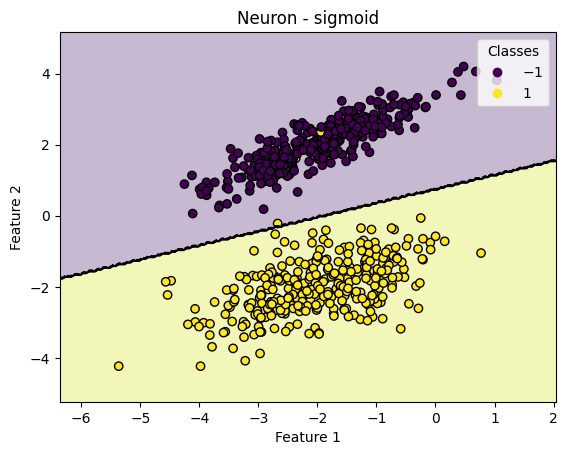

In [38]:
neuron = Neuron(input_dim = X_train.shape[1], lr=0.1, activation='sigmoid')
neuron.fit(X_train, y_train, epochs=100)
y_pred = neuron.predict(X_test)
print(f"Accuracy: {np.mean(y_pred == y_test)}")
plot_decision_boundary(X_test, y_test, neuron, "Neuron - sigmoid")

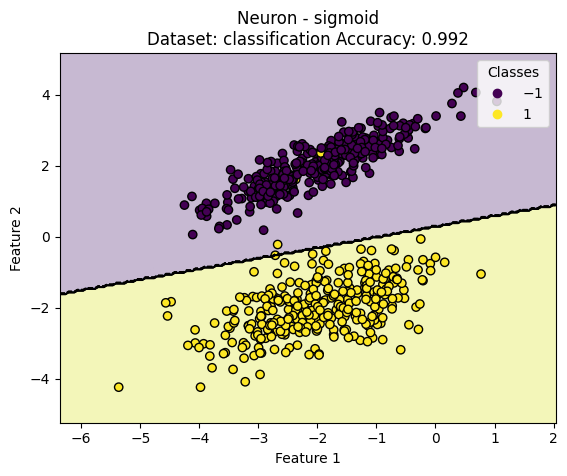

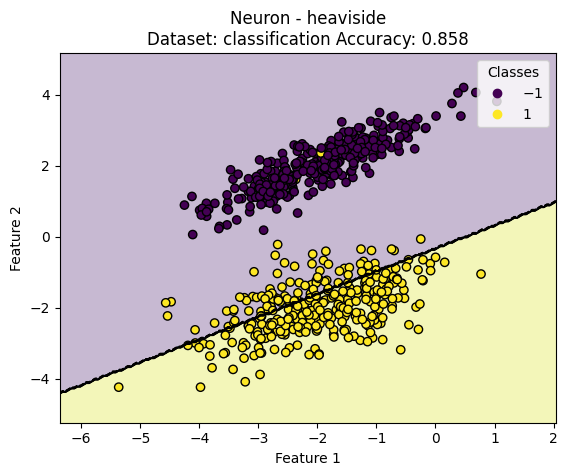

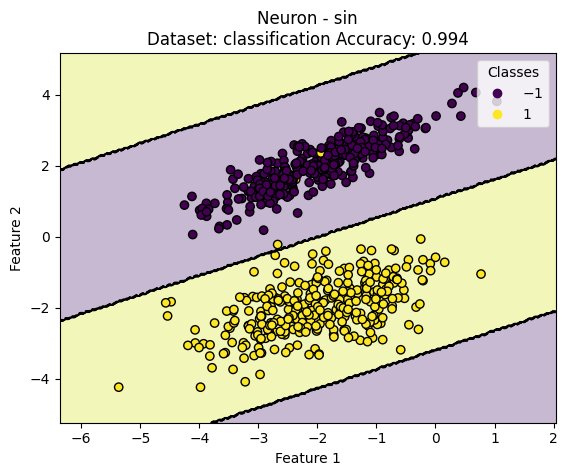

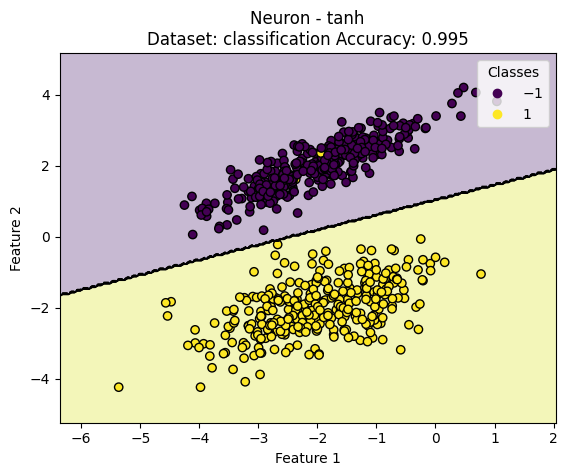

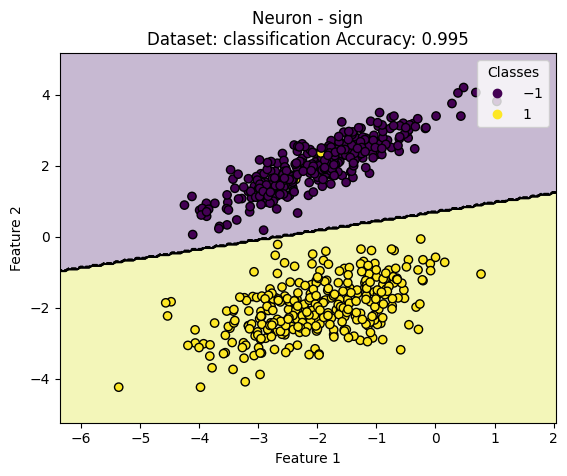

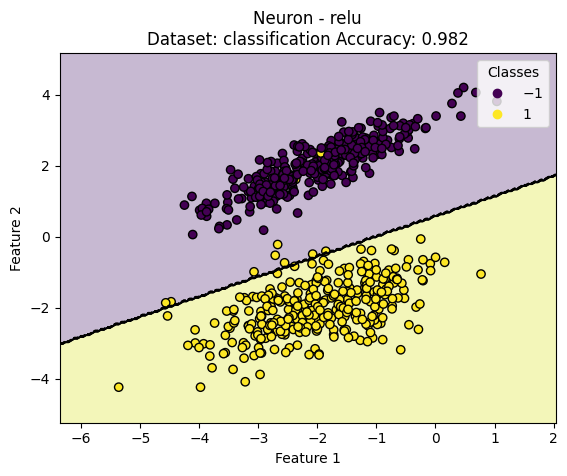

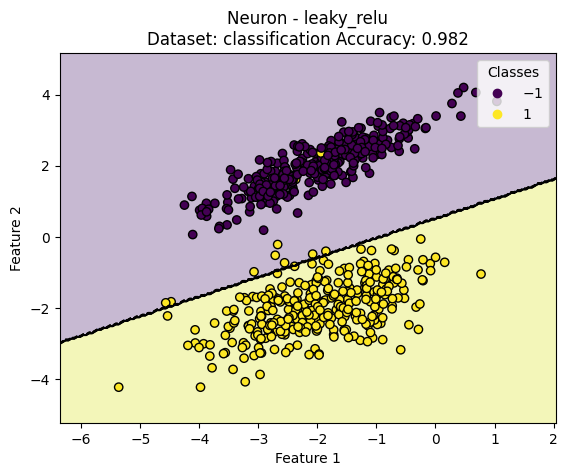

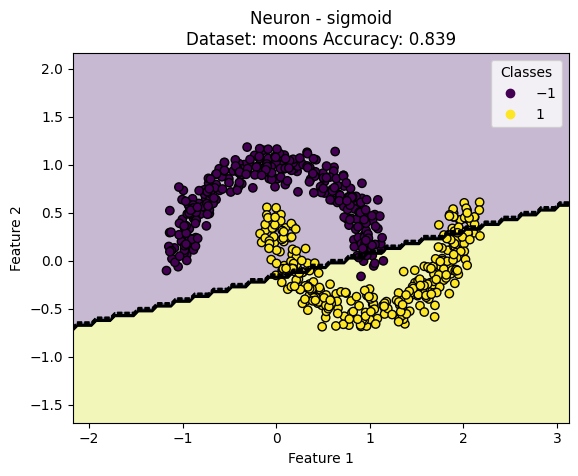

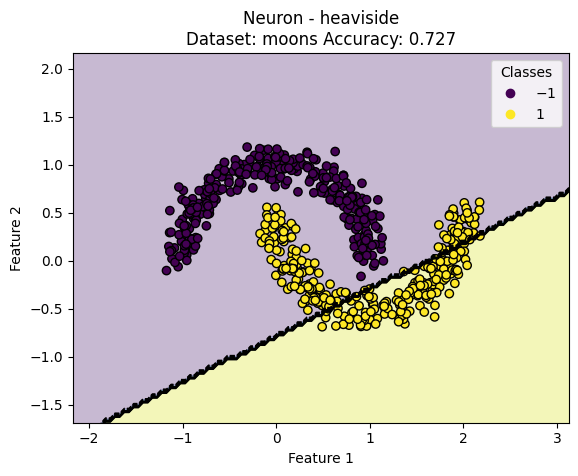

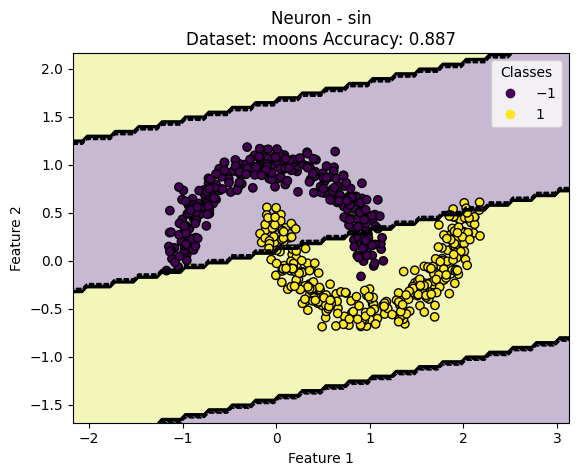

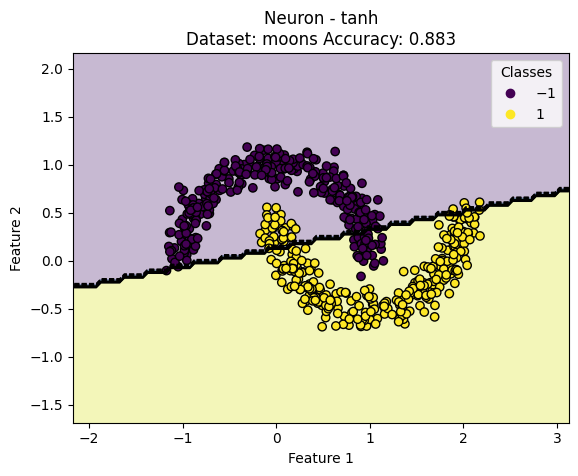

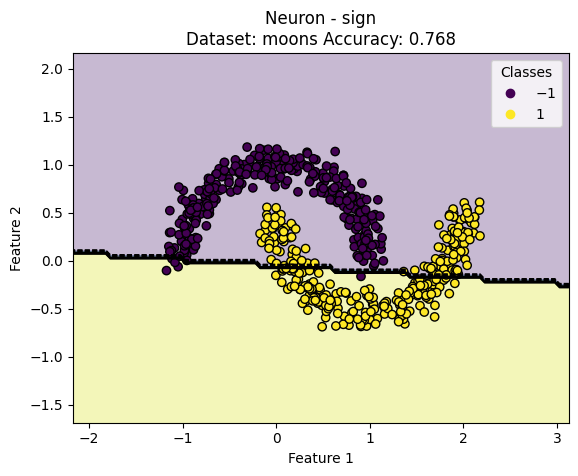

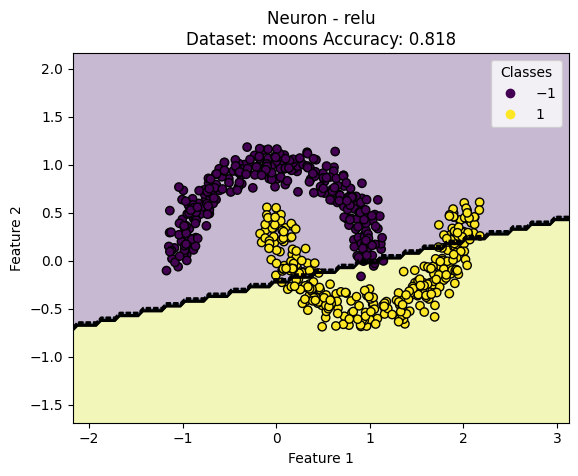

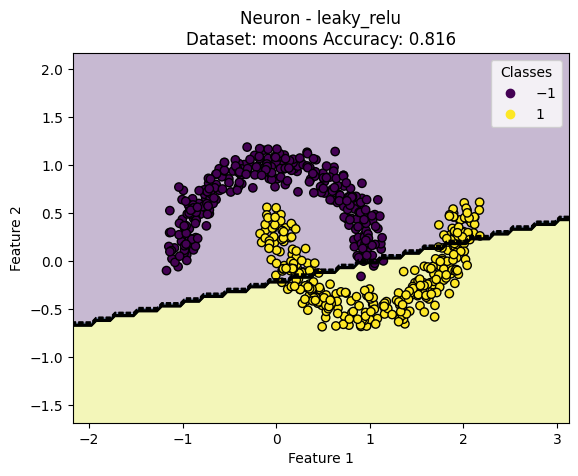

In [39]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
}
results = []
activation_functions = ['sigmoid', 'heaviside', 'sin', 'tanh', 'sign', 'relu', 'leaky_relu']

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    for activation in activation_functions:
        neuron = Neuron(input_dim = X_tr.shape[1], 
                        lr=0.01, 
                        activation=activation,
                        lr_min=None, 
                        lr_max=None, 
                        batch_size=None)
        neuron.fit(X_tr, y_tr, epochs=100)
        y_pr = neuron.predict(X_te)
        y_sc = neuron.predict_proba(X_te)
        acc = np.mean(y_pr == y_te)
        plot_decision_boundary(X_te, y_te, neuron, f"Neuron - {activation}\nDataset: {ds_name} Accuracy: {acc:.3f}")
        results.append({
                'activation': activation,
                'dataset': ds_name,
                'accuracy': acc,
                'model': neuron,
                'y_pred': y_pr,
                'y_score': y_sc,
                'y_true': y_te
            })

# Evaluation

In [68]:
pd.DataFrame(results).drop(columns=['y_pred','y_score', 'y_true', 'model']).sort_values(by=['accuracy'], ascending=False)

,activation,dataset,accuracy
3,tanh,classification,0.995208
0,sigmoid,classification,0.993610
5,relu,classification,0.992013
6,leaky_relu,classification,0.992013
1,heaviside,classification,0.985623
7,sigmoid,moons,0.886581
9,sin,moons,0.884984
12,relu,moons,0.884984
13,leaky_relu,moons,0.884984
10,tanh,moons,0.880192


In [69]:
times = []

for row in results:
    ds_name = row['dataset']
    model = row['model']

    X_tr, y_tr = datasets[ds_name][0:2]

    iterations = 10
    t0 = time.time()
    for _ in range(iterations):
        model.fit(X_tr, y_tr)
    t1 = time.time() - t0

    times.append({
        'activation': row['activation'],
        'dataset': ds_name,
        'time': t1/iterations,
    })

In [70]:
times_df = pd.DataFrame(times)
times_df.sort_values(by=['time'], ascending=False)

,activation,dataset,time
13,leaky_relu,moons,2.201791
6,leaky_relu,classification,1.828053
11,sign,moons,1.815720
1,heaviside,classification,1.772097
8,heaviside,moons,1.611186
4,sign,classification,1.305724
12,relu,moons,1.303571
10,tanh,moons,1.296252
9,sin,moons,1.175643
7,sigmoid,moons,1.100298


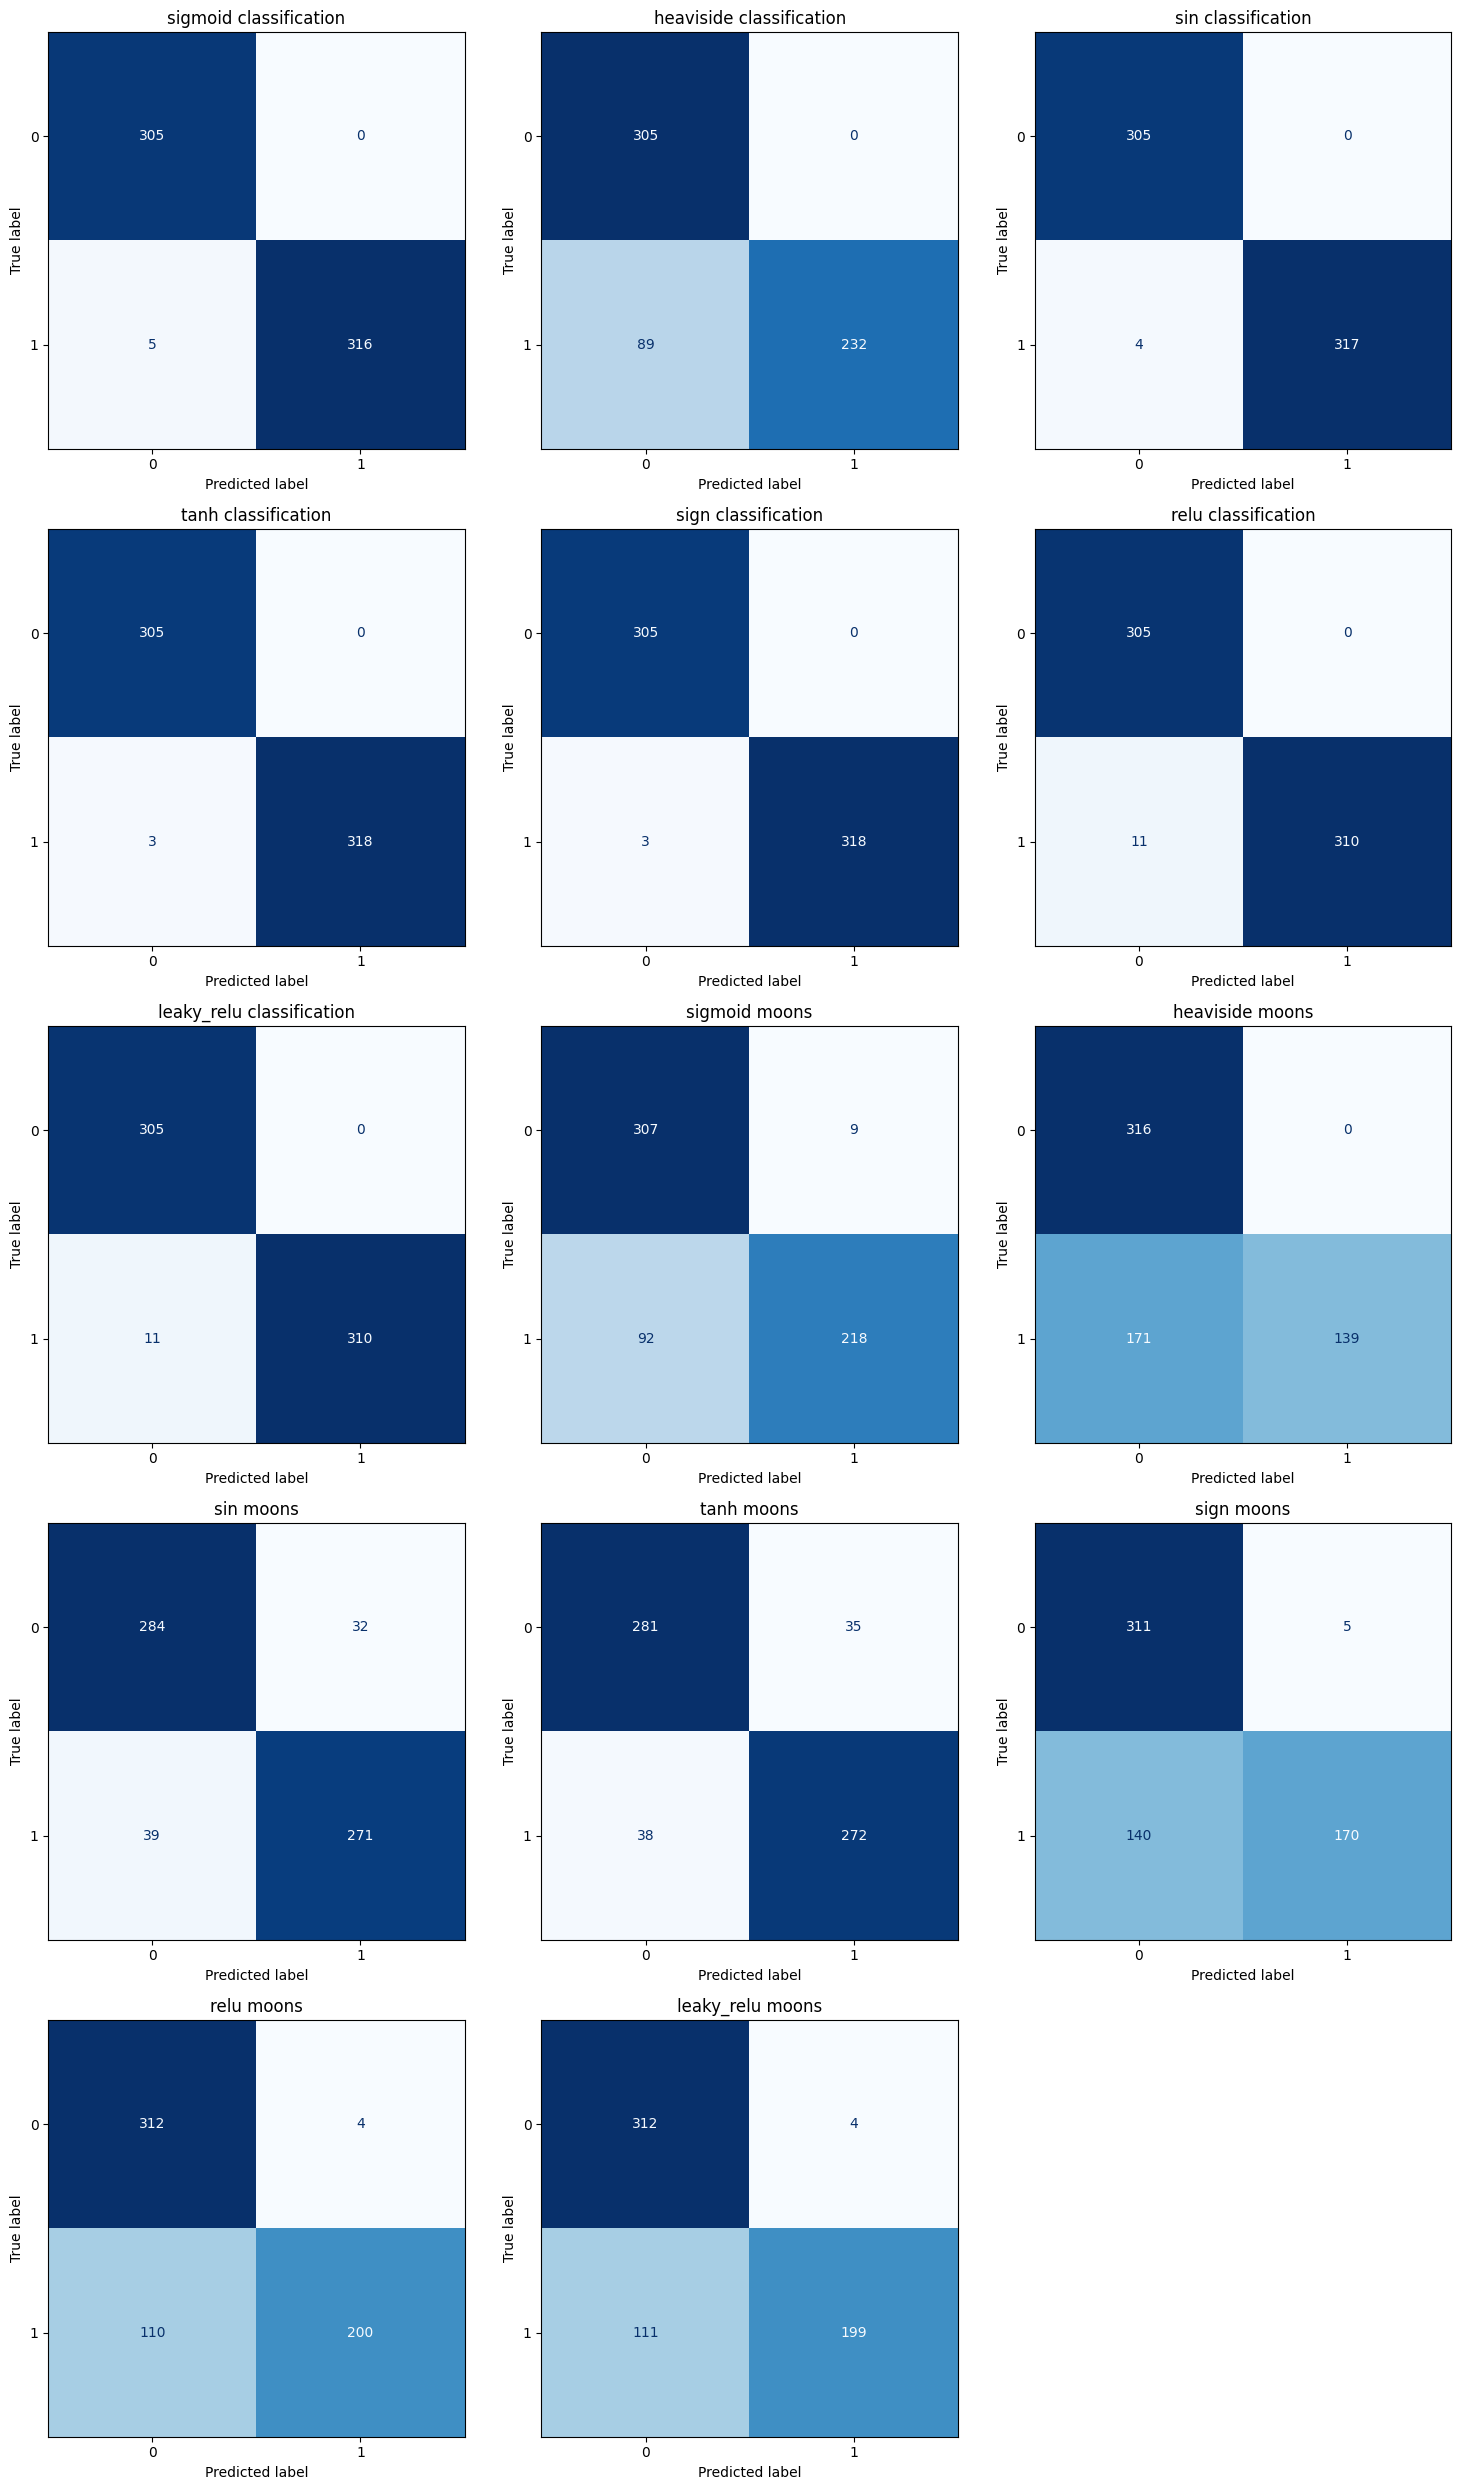

In [40]:
cms = {}
n_cols = 3
n_rows = (len(results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, row in enumerate(results):
    cm = confusion_matrix(row['y_true'], row['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    cm_title = f"{row['activation']} {row['dataset']}"
    axes[i].set_title(cm_title)
    cms[cm_title] = cm
    
for j in range(i + 1, len(axes)):
    axes[j].axis('off')  # Hide unused subplots
plt.tight_layout()
plt.show()

In [41]:
stats_df = pd.DataFrame(columns=['dataset', 'activation', 'specificity', 'sensitivity'])

for cm_name, cm_matrix in cms.items():
    parts = cm_name.split()
    dataset = parts[0]
    activation_type = parts[1]

    tn, fp, fn, tp = cm_matrix.ravel()
    specificity = tn / (tn+fp) if (tn+fp) > 0 else 0
    sensitivity = tp / (tp+fn) if (tp+fn) > 0 else 0

    stats_df.loc[len(stats_df)] = [activation_type, dataset, specificity, sensitivity]

stats_df = stats_df.round(3)
stats_df

,dataset,activation,specificity,sensitivity
0,classification,sigmoid,1.000,0.984
1,classification,heaviside,1.000,0.723
2,classification,sin,1.000,0.988
3,classification,tanh,1.000,0.991
4,classification,sign,1.000,0.991
5,classification,relu,1.000,0.966
6,classification,leaky_relu,1.000,0.966
7,moons,sigmoid,0.972,0.703
8,moons,heaviside,1.000,0.448
9,moons,sin,0.899,0.874


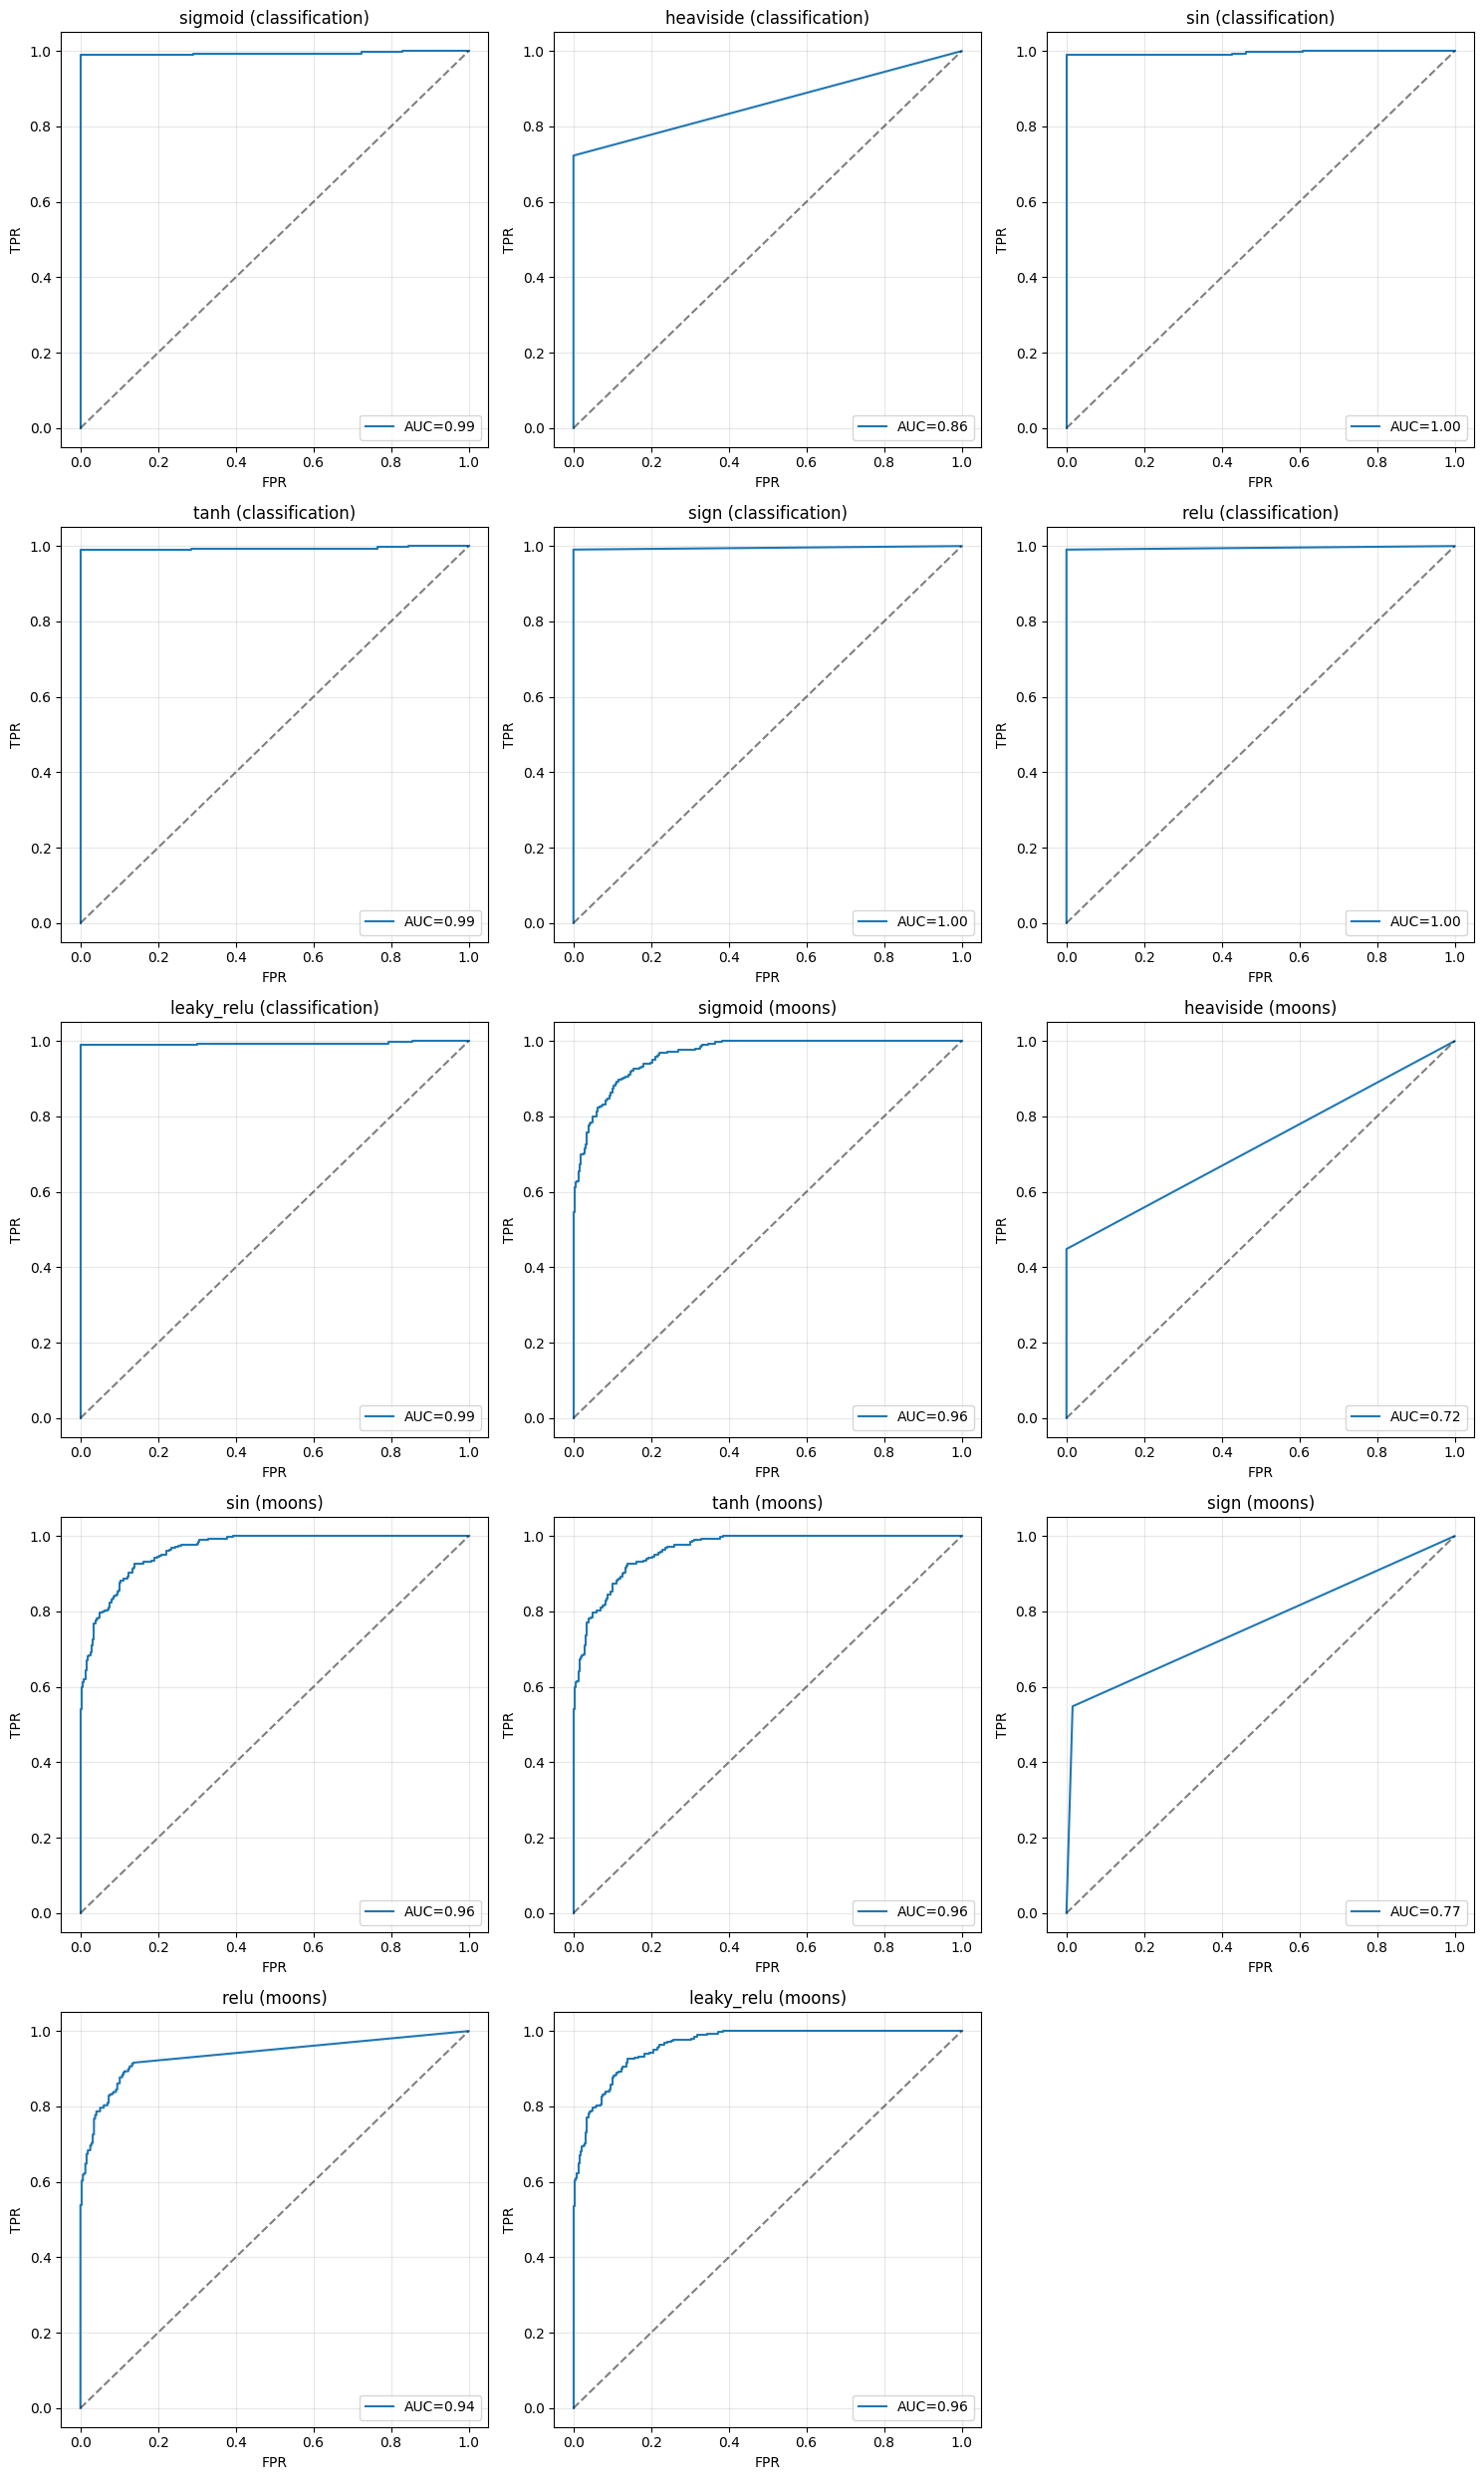

In [42]:
n_plots = len(results)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, row in enumerate(results):
    if i >= len(axes):
        break

    activation_type = row['activation']
    dataset = row['dataset']
    y_true = row['y_true']
    y_score = row['y_score']

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].set_title(f"{activation_type} ({dataset})")
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Variable Learning Rate (Cosine Annealing) and Batches

In [43]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
}
activation_functions = ['sigmoid', 'heaviside', 'sin', 'tanh', 'sign', 'relu', 'leaky_relu']
batch_sizes = [None, 8, 32, 64, 128]
cosine_annealing_options = [False, True]

all_results = []

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    for activation in activation_functions:
        for use_cosine_annealing in cosine_annealing_options:
            for batch_size in batch_sizes:

                if use_cosine_annealing:
                    lr_min = 0.001
                    lr_max = 0.01
                else:
                    lr_min = lr_max = 0.01

                neuron = Neuron(
                    input_dim=X_tr.shape[1],
                    lr=0.01,
                    activation=activation,
                    lr_min=lr_min,
                    lr_max=lr_max,
                    batch_size=batch_size
                )
                neuron.fit(X_tr, y_tr, epochs=100)
                y_pr = neuron.predict(X_te)
                y_sc = neuron.predict_proba(X_te)
                acc = np.mean(y_pr == y_te)
                all_results.append({
                    'activation': activation,
                    'dataset': ds_name,
                    'accuracy': acc,
                    'model': neuron,
                    'y_pred': y_pr,
                    'y_score': y_sc,
                    'y_true': y_te,
                    'cosine_annealing': use_cosine_annealing,
                    'batch_size': batch_size
                })

In [44]:
pd.DataFrame(all_results).drop(columns=['y_pred', 'y_score', 'y_true', 'model']).sort_values(by=['accuracy'], ascending=False).head(10)

,activation,dataset,accuracy,cosine_annealing,batch_size
40,sign,classification,0.995208,False,NaN
22,sin,classification,0.995208,False,32.0
45,sign,classification,0.995208,True,NaN
35,tanh,classification,0.995208,True,NaN
30,tanh,classification,0.995208,False,NaN
25,sin,classification,0.993610,True,NaN
0,sigmoid,classification,0.993610,False,NaN
20,sin,classification,0.993610,False,NaN
5,sigmoid,classification,0.992013,True,NaN
24,sin,classification,0.992013,False,128.0


In [45]:
df = pd.DataFrame(all_results).drop(columns=['y_pred', 'y_score', 'y_true', 'model'])
df.sort_values('accuracy', ascending=False).groupby('dataset').head(3)

,activation,dataset,accuracy,cosine_annealing,batch_size
40,sign,classification,0.995208,False,NaN
22,sin,classification,0.995208,False,32.0
45,sign,classification,0.995208,True,NaN
95,sin,moons,0.888179,True,NaN
90,sin,moons,0.886581,False,NaN
105,tanh,moons,0.884984,True,NaN
